In [1]:
# Phase 12 – Hierarchical RL | Cell 1: Setup + Load models

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import sys
import pickle

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR   = PROJECT / "outputs" / "phase12"
OUT_DATA  = OUT_DIR / "data"
OUT_TAB   = OUT_DIR / "tables"
OUT_FIG   = OUT_DIR / "figures"
for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

P8  = PROJECT / "outputs" / "phase8" / "data"
P9  = PROJECT / "outputs" / "phase9"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11"

print("=" * 60)
print("Phase 12 – Hierarchical RL | Cell 1")
print("=" * 60)
print(f"Timestamp : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Outputs   : {OUT_DIR}")

for p in [str(P8), str(P10), str(P11 / "data")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_env import EconomicsNetworkEnv
from shock_env import ShockEconomicsEnv
from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

# ---- Stage I: PPO phase9 winner ----
from stable_baselines3 import PPO, TD3

ppo_path = P9 / "models" / "PPO_moderate_gs.zip"
if not ppo_path.exists():
    # fallback patterns
    for c in [P9 / "models" / "PPO_moderate.zip", P9 / "models" / "PPO_moderate_gs.zip"]:
        if c.exists():
            ppo_path = c
            break
stage1_ppo = PPO.load(str(ppo_path))
print(f"Stage I PPO loaded: {ppo_path}")

# ---- Stage II / Flat: TD3 phase11 ----
td3_candidates = [
    P11 / "models" / "TD3_standard_r.zip",
    P11 / "models" / "TD3_strong_r.zip",
    P11 / "models" / "TD3_standard.zip",
]
td3_models = {}
for series in ["standard", "strong"]:
    path = P11 / "models" / f"TD3_{series}_r.zip"
    if not path.exists():
        path = P11 / "models" / f"TD3_{series}.zip"
    if path.exists():
        td3_models[series] = TD3.load(str(path))
        print(f"TD3 [{series}] loaded: {path.name}")
    else:
        print(f"WARNING: TD3 {series} not found")

# ---- Stage II: MAPPO phase11 RLlib checkpoints ----
mappo_ckpts = {}
for series in ["standard", "strong"]:
    # RLlib save() creates a directory
    cands = [
        P11 / "models" / f"MAPPO_{series}_rllib",
        P11 / "models" / f"MAPPO_{series}",
    ]
    path = next((c for c in cands if c.exists()), None)
    mappo_ckpts[series] = path
    print(f"MAPPO [{series}] ckpt: {path}")

print(f"\nbase_features: {base_features.shape} | emb: {emb.shape}")
print(f"Agents: {AGENTS}")
print("Cell 1 completed successfully.")

Phase 12 – Hierarchical RL | Cell 1
Timestamp : 2026-10-03 10:02:51
Outputs   : D:\univercity\omid_project\economics_project\outputs\phase12
Stage I PPO loaded: D:\univercity\omid_project\economics_project\outputs\phase9\models\PPO_moderate_gs.zip
TD3 [standard] loaded: TD3_standard_r.zip
TD3 [strong] loaded: TD3_strong_r.zip
MAPPO [standard] ckpt: D:\univercity\omid_project\economics_project\outputs\phase11\models\MAPPO_standard_rllib
MAPPO [strong] ckpt: D:\univercity\omid_project\economics_project\outputs\phase11\models\MAPPO_strong_rllib

base_features: (378, 16) | emb: (378, 32)
Agents: ['Government', 'CentralBank', 'BankingSector']
Cell 1 completed successfully.


In [3]:
# Phase 12 – Cell 2B: Re-register env + load MAPPO checkpoints

from pathlib import Path
import sys
import numpy as np
import ray
from ray.tune.registry import register_env
from ray.rllib.env.wrappers.pettingzoo_env import ParallelPettingZooEnv
from ray.rllib.algorithms.algorithm import Algorithm

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11"

for p in [str(P8), str(P10), str(P11 / "data")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_ma_pettingzoo import EconomicsMAParallelEnv

print("=" * 60)
print("Phase 12 – Cell 2B: register_env + restore MAPPO")
print("=" * 60)

if not ray.is_initialized():
    ray.init(ignore_reinit_error=True, include_dashboard=False, logging_level="ERROR")

base_features = np.load(P8 / "base_features.npy")
emb = np.load(P8 / "emb_GraphSAGE.npy")
sr_vector = np.load(P8 / "sr_vector.npy")
panel = pd.read_csv(P8 / "panel_index.csv")
nodes = pd.read_csv(P8 / "node_list.csv")["iso2"].tolist()

TRAIN_SHOCK = ("BankingCrisis", "Moderate")
SEED = 0

def make_raw_env(series, seed=SEED):
    return EconomicsMAParallelEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type=TRAIN_SHOCK[0], severity=TRAIN_SHOCK[1],
        shock_series=series, seed=seed,
    )

# همان نام‌هایی که در فاز ۱۱ برای MAPPO ثبت شده بود
for series in ["standard", "strong"]:
    env_name = f"econ_ma_{series}_mappo"
    def _creator(config, series=series):
        return ParallelPettingZooEnv(make_raw_env(series, SEED))
    register_env(env_name, _creator)
    print(f"Registered: {env_name}")

mappo_algos = {}
for series in ["standard", "strong"]:
    path = P11 / "models" / f"MAPPO_{series}_rllib"
    if not path.exists():
        print(f"Missing: {path}")
        continue
    # RLlib often saves into a subfolder; try path and children
    candidates = [path] + [p for p in path.rglob("*") if p.is_dir()]
    loaded = False
    for c in candidates:
        try:
            algo = Algorithm.from_checkpoint(str(c))
            mappo_algos[series] = algo
            print(f"MAPPO [{series}] restored from {c}")
            loaded = True
            break
        except Exception as e:
            last_err = e
            continue
    if not loaded:
        print(f"FAILED MAPPO [{series}]: {last_err}")

print("Loaded series:", list(mappo_algos.keys()))
print("Cell 2B completed successfully.")

Phase 12 – Cell 2B: register_env + restore MAPPO
Registered: econ_ma_standard_mappo
Registered: econ_ma_strong_mappo
MAPPO [standard] restored from D:\univercity\omid_project\economics_project\outputs\phase11\models\MAPPO_standard_rllib
MAPPO [strong] restored from D:\univercity\omid_project\economics_project\outputs\phase11\models\MAPPO_strong_rllib
Loaded series: ['standard', 'strong']
Cell 2B completed successfully.


In [4]:
# Phase 12 – Cell 2C: Hierarchical & Flat runners + smoke test

import numpy as np
import pandas as pd

print("=" * 60)
print("Phase 12 – Cell 2C: Runners")
print("=" * 60)

STAGE1_STEPS = 10
STAGE2_STEPS = 30
EVAL_EPISODES = 20
SEEDS = [0, 1, 2]

def stage1_action(obs_vec):
    a, _ = stage1_ppo.predict(obs_vec, deterministic=True)
    return np.asarray(a, dtype=np.float32).reshape(-1)

def td3_joint_to_ma(obs_vec, series):
    a, _ = td3_models[series].predict(obs_vec, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    if a.size < 6:
        a = np.pad(a, (0, 6 - a.size))
    return {
        "Government": a[0:2],
        "CentralBank": a[2:4],
        "BankingSector": a[4:6],
    }

def mappo_ma_action(obs_dict, series):
    algo = mappo_algos[series]
    actions = {}
    for agent, o in obs_dict.items():
        try:
            act = algo.compute_single_action(o, policy_id="shared_policy")
        except Exception:
            act = algo.compute_single_action(o)
        if isinstance(act, tuple):
            act = act[0]
        actions[agent] = np.asarray(act, dtype=np.float32)
    return actions

def run_hierarchical(series, stage2="MAPPO", seed=0):
    env1 = EconomicsNetworkEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", seed=seed,
    )
    obs, info = env1.reset(seed=seed)
    ep_r = 0.0
    for _ in range(STAGE1_STEPS):
        a = stage1_action(obs)
        adim = env1.action_space.shape[0]
        if a.size < adim:
            a = np.pad(a, (0, adim - a.size))
        obs, r, term, trunc, info = env1.step(a[:adim])
        ep_r += float(r)
        if term or trunc:
            break

    features_s1 = env1.current_features.copy()
    sr_s1 = float(np.mean(env1.current_sr)) if np.ndim(env1.current_sr) else float(env1.current_sr)

    env2 = EconomicsMAParallelEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type="BankingCrisis", severity="Moderate",
        shock_series=series, seed=seed + 100,
    )
    obs_dict, infos = env2.reset(seed=seed + 100)
    env2._base.current_features = 0.5 * env2._base.current_features + 0.5 * features_s1
    sr_after_shock = float(np.mean(env2._base.current_sr))

    for _ in range(STAGE2_STEPS):
        if not env2.agents:
            break
        if stage2 == "MAPPO":
            ad = mappo_ma_action(obs_dict, series)
        else:
            o = next(iter(obs_dict.values()))
            ad = td3_joint_to_ma(o, series)
        obs_dict, rews, terms, truncs, infos = env2.step(ad)
        ep_r += float(np.mean(list(rews.values())))
        if any(terms.values()) or any(truncs.values()):
            break

    sr_end = float(np.mean(env2._base.current_sr))
    info_last = list(infos.values())[0] if infos else {}
    return {
        "reward": ep_r,
        "sr_after_stage1": sr_s1,
        "sr_after_shock": sr_after_shock,
        "sr_end": sr_end,
        "recovery": sr_end - sr_after_shock,
        "sr_improve": info_last.get("sr_improve", np.nan),
    }

def run_flat(series, policy="MAPPO", seed=0):
    env = EconomicsMAParallelEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type="BankingCrisis", severity="Moderate",
        shock_series=series, seed=seed,
    )
    obs_dict, infos = env.reset(seed=seed)
    sr0 = float(np.mean(env._base.current_sr))
    ep_r = 0.0
    for _ in range(STAGE1_STEPS + STAGE2_STEPS):
        if not env.agents:
            break
        if policy == "MAPPO":
            ad = mappo_ma_action(obs_dict, series)
        else:
            o = next(iter(obs_dict.values()))
            ad = td3_joint_to_ma(o, series)
        obs_dict, rews, terms, truncs, infos = env.step(ad)
        ep_r += float(np.mean(list(rews.values())))
        if any(terms.values()) or any(truncs.values()):
            break
    sr_end = float(np.mean(env._base.current_sr))
    info_last = list(infos.values())[0] if infos else {}
    return {
        "reward": ep_r,
        "sr_after_stage1": np.nan,
        "sr_after_shock": sr0,
        "sr_end": sr_end,
        "recovery": sr_end - sr0,
        "sr_improve": info_last.get("sr_improve", np.nan),
    }

# smoke
for series in ["standard", "strong"]:
    h_m = run_hierarchical(series, "MAPPO", 0)
    h_t = run_hierarchical(series, "TD3", 0)
    f_m = run_flat(series, "MAPPO", 0)
    f_t = run_flat(series, "TD3", 0)
    print(f"[{series}] Hier-MAPPO R={h_m['reward']:.3f} rec={h_m['recovery']:.3f} | "
          f"Hier-TD3 R={h_t['reward']:.3f} rec={h_t['recovery']:.3f}")
    print(f"[{series}] Flat-MAPPO R={f_m['reward']:.3f} rec={f_m['recovery']:.3f} | "
          f"Flat-TD3  R={f_t['reward']:.3f} rec={f_t['recovery']:.3f}")

print("\nCell 2C completed successfully.")

Phase 12 – Cell 2C: Runners
[standard] Hier-MAPPO R=1.688 rec=0.533 | Hier-TD3 R=11.720 rec=1.098
[standard] Flat-MAPPO R=6.486 rec=0.824 | Flat-TD3  R=22.523 rec=1.316
[strong] Hier-MAPPO R=-3.983 rec=0.401 | Hier-TD3 R=6.159 rec=0.963
[strong] Flat-MAPPO R=-5.553 rec=0.447 | Flat-TD3  R=15.438 rec=1.269

Cell 2C completed successfully.


In [5]:
# Phase 12 – Cell 3: Full evaluation grid

print("=" * 60)
print("Phase 12 – Cell 3: Full evaluation")
print("=" * 60)

rows = []
configs = [
    ("hierarchical", "MAPPO"),
    ("hierarchical", "TD3"),
    ("flat", "MAPPO"),
    ("flat", "TD3"),
]

for series in ["standard", "strong"]:
    for arch, pol in configs:
        for seed in SEEDS:
            ep_stats = []
            for ep in range(EVAL_EPISODES):
                s = seed * 1000 + ep
                if arch == "hierarchical":
                    st = run_hierarchical(series, stage2=pol, seed=s)
                else:
                    st = run_flat(series, policy=pol, seed=s)
                ep_stats.append(st)
            rewards = [x["reward"] for x in ep_stats]
            recs = [x["recovery"] for x in ep_stats]
            rows.append({
                "series": series,
                "architecture": arch,
                "stage2_policy": pol,
                "seed": seed,
                "mean_reward": float(np.mean(rewards)),
                "std_reward": float(np.std(rewards)),
                "median_reward": float(np.median(rewards)),
                "mean_recovery": float(np.mean(recs)),
                "std_recovery": float(np.std(recs)),
            })
        print(f"done {arch:13s} | {pol:5s} | {series}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase12_eval_raw.csv", index=False)

summary = (
    df.groupby(["series", "architecture", "stage2_policy"], as_index=False)
      .agg(
          mean_reward=("mean_reward", "mean"),
          std_across_seeds=("mean_reward", "std"),
          mean_recovery=("mean_recovery", "mean"),
          std_recovery=("std_recovery", "mean"),
      )
)
summary.to_csv(OUT_TAB / "phase12_eval_summary.csv", index=False)
print("\n", summary.sort_values(["series", "mean_reward"], ascending=[True, False]).to_string(index=False))
print("\nCell 3 completed successfully.")

Phase 12 – Cell 3: Full evaluation
done hierarchical  | MAPPO | standard
done hierarchical  | TD3   | standard
done flat          | MAPPO | standard
done flat          | TD3   | standard
done hierarchical  | MAPPO | strong
done hierarchical  | TD3   | strong
done flat          | MAPPO | strong
done flat          | TD3   | strong

   series architecture stage2_policy  mean_reward  std_across_seeds  mean_recovery  std_recovery
standard         flat           TD3    23.176706          0.204227       1.305828      0.010874
standard hierarchical           TD3    12.278167          0.092213       1.111262      0.015470
standard         flat         MAPPO     5.872593          0.177042       0.757144      0.050920
standard hierarchical         MAPPO     1.973144          0.096316       0.550170      0.044916
  strong         flat           TD3    12.658202          0.204070       1.200640      0.032509
  strong hierarchical           TD3     5.537205          0.084595       0.923793      0.03

Phase 12 – Cell 4: Final comparison

=== Hierarchical vs Flat ===
  series stage2_policy  flat_reward  hier_reward  delta_reward_hier_minus_flat  flat_recovery  hier_recovery  delta_recovery_hier_minus_flat winner_reward winner_recovery
standard           TD3    23.176706    12.278167                    -10.898540       1.305828       1.111262                       -0.194566          flat            flat
standard         MAPPO     5.872593     1.973144                     -3.899449       0.757144       0.550170                       -0.206975          flat            flat
  strong           TD3    12.658202     5.537205                     -7.120997       1.200640       0.923793                       -0.276848          flat            flat
  strong         MAPPO    -6.107669    -4.686893                      1.420776       0.422007       0.348338                       -0.073669  hierarchical            flat

=== Full ranking by reward ===
  series architecture stage2_policy  mean_rewar

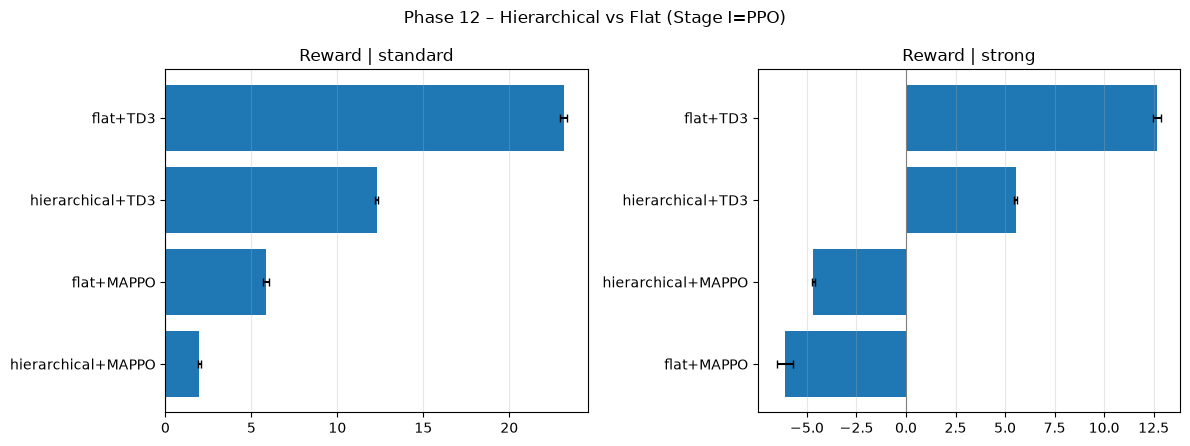

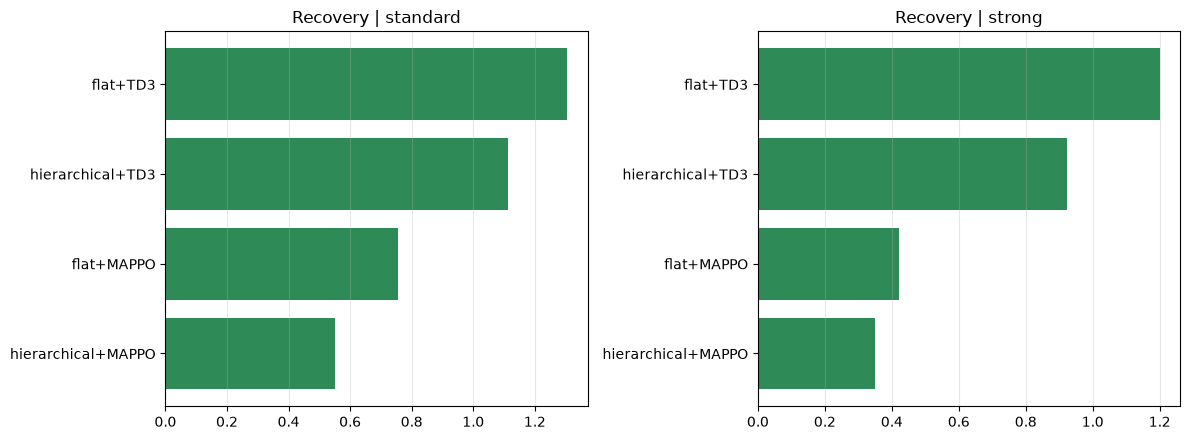


Saved → D:\univercity\omid_project\economics_project\outputs\phase12\tables\phase12_hier_vs_flat.csv
Cell 4 completed successfully.
PHASE 12 EVALUATION COMPLETED.


In [6]:
# Phase 12 – Cell 4: Comparison table + figures

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase12" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase12" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase12" / "data"

print("=" * 60)
print("Phase 12 – Cell 4: Final comparison")
print("=" * 60)

summary = pd.read_csv(OUT_TAB / "phase12_eval_summary.csv")

# pivot-style comparison table
rows = []
for series in ["standard", "strong"]:
    sub = summary[summary.series == series]
    for pol in ["TD3", "MAPPO"]:
        flat = sub[(sub.architecture == "flat") & (sub.stage2_policy == pol)]
        hier = sub[(sub.architecture == "hierarchical") & (sub.stage2_policy == pol)]
        if len(flat) == 0 or len(hier) == 0:
            continue
        fr, hr = float(flat.mean_reward.iloc[0]), float(hier.mean_reward.iloc[0])
        frec, hrec = float(flat.mean_recovery.iloc[0]), float(hier.mean_recovery.iloc[0])
        rows.append({
            "series": series,
            "stage2_policy": pol,
            "flat_reward": fr,
            "hier_reward": hr,
            "delta_reward_hier_minus_flat": hr - fr,
            "flat_recovery": frec,
            "hier_recovery": hrec,
            "delta_recovery_hier_minus_flat": hrec - frec,
            "winner_reward": "hierarchical" if hr > fr else "flat",
            "winner_recovery": "hierarchical" if hrec > frec else "flat",
        })

cmp = pd.DataFrame(rows)
cmp.to_csv(OUT_TAB / "phase12_hier_vs_flat.csv", index=False)

print("\n=== Hierarchical vs Flat ===")
print(cmp.to_string(index=False))

print("\n=== Full ranking by reward ===")
print(summary.sort_values(["series", "mean_reward"], ascending=[True, False]).to_string(index=False))

# bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
for ax, series in zip(axes, ["standard", "strong"]):
    sub = summary[summary.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["stage2_policy"]
    sub = sub.sort_values("mean_reward")
    ax.barh(sub["label"], sub["mean_reward"], xerr=sub["std_across_seeds"], capsize=3)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_title(f"Reward | {series}")
    ax.grid(True, axis="x", alpha=0.3)
fig.suptitle("Phase 12 – Hierarchical vs Flat (Stage I=PPO)")
plt.tight_layout()
fig.savefig(OUT_FIG / "phase12_hier_vs_flat_reward.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series in zip(axes, ["standard", "strong"]):
    sub = summary[summary.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["stage2_policy"]
    sub = sub.sort_values("mean_recovery")
    ax.barh(sub["label"], sub["mean_recovery"], color="seagreen")
    ax.set_title(f"Recovery | {series}")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase12_hier_vs_flat_recovery.png", dpi=150)
plt.show()

print(f"\nSaved → {OUT_TAB / 'phase12_hier_vs_flat.csv'}")
print("Cell 4 completed successfully.")
print("PHASE 12 EVALUATION COMPLETED.")

Phase 12 – Cell 5: SR structural metrics + multi-scenario stability
done standard | BankingCrisis/Moderate
done standard | BankingCrisis/Severe
done standard | Recession/Moderate
done standard | Recession/Severe
done standard | DebtCrisis/Moderate
done standard | Inflation/Severe
done strong | BankingCrisis/Moderate
done strong | BankingCrisis/Severe
done strong | Recession/Moderate
done strong | Recession/Severe
done strong | DebtCrisis/Moderate
done strong | Inflation/Severe

=== Ranking by structural end-state SR (mean_sr_end) ===
  series architecture stage2_policy  mean_sr_end  std_sr_end_across_scenarios  mean_recovery  mean_reward  stability_sr_end
standard         flat           TD3     1.495170                     0.003079       1.303553    23.158947          0.996931
standard hierarchical           TD3     1.297517                     0.037209       1.110319    12.220292          0.964126
standard         flat         MAPPO     0.933820                     0.033082       0.74

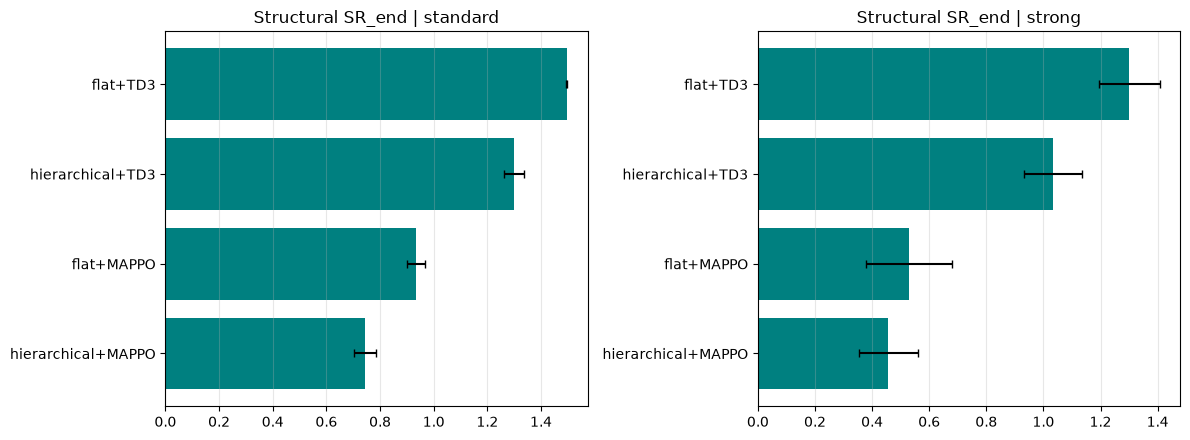

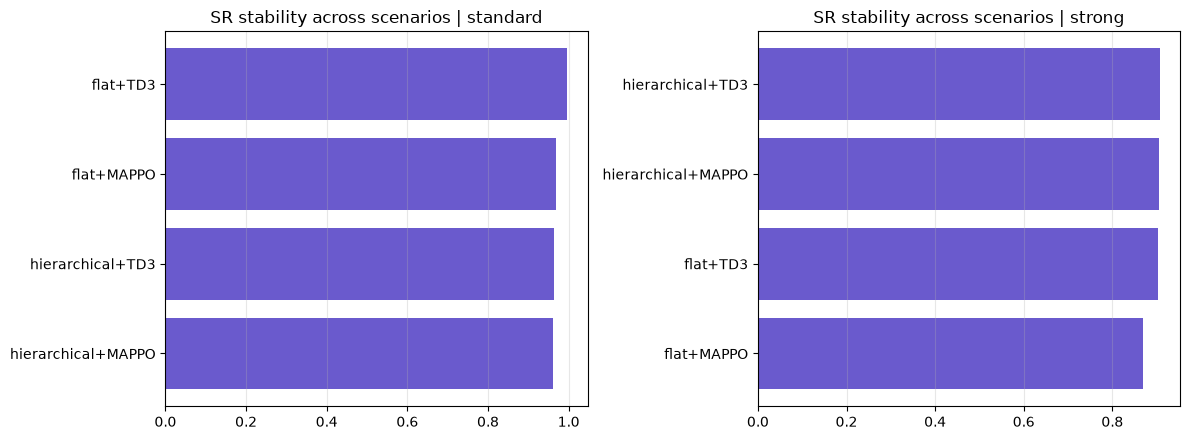


Saved → D:\univercity\omid_project\economics_project\outputs\phase12\tables\phase12_sr_stability_summary.csv
Saved → D:\univercity\omid_project\economics_project\outputs\phase12\tables\phase12_hier_vs_flat_SR.csv

Cell 5 completed successfully.


In [7]:
# Phase 12 – Cell 5: SR structural end-state + cross-scenario stability

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11"
OUT_TAB = PROJECT / "outputs" / "phase12" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase12" / "figures"

for p in [str(P8), str(P10), str(P11 / "data")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from economics_ma_pettingzoo import EconomicsMAParallelEnv, AGENTS
from economics_env import EconomicsNetworkEnv

print("=" * 60)
print("Phase 12 – Cell 5: SR structural metrics + multi-scenario stability")
print("=" * 60)

# Reuse runners from Cell 2C (must already be in kernel):
# run_hierarchical, run_flat, stage1_ppo, td3_models, mappo_algos

N_EP = 15
SEEDS = [0, 1]
SERIES_LIST = ["standard", "strong"]
# multi-scenario shocks (type, severity)
SCENARIOS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("Recession", "Severe"),
    ("DebtCrisis", "Moderate"),
    ("Inflation", "Severe"),
]

def run_hierarchical_scenario(series, stage2, shock_type, severity, seed):
    # Stage I
    env1 = EconomicsNetworkEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", seed=seed,
    )
    obs, info = env1.reset(seed=seed)
    ep_r = 0.0
    for _ in range(STAGE1_STEPS):
        a = stage1_action(obs)
        adim = env1.action_space.shape[0]
        if a.size < adim:
            a = np.pad(a, (0, adim - a.size))
        obs, r, term, trunc, info = env1.step(a[:adim])
        ep_r += float(r)
        if term or trunc:
            break
    features_s1 = env1.current_features.copy()
    sr_s1 = float(np.mean(env1.current_sr)) if np.ndim(env1.current_sr) else float(env1.current_sr)

    env2 = EconomicsMAParallelEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type=shock_type, severity=severity,
        shock_series=series, seed=seed + 100,
    )
    obs_dict, infos = env2.reset(seed=seed + 100)
    env2._base.current_features = 0.5 * env2._base.current_features + 0.5 * features_s1
    sr_shock = float(np.mean(env2._base.current_sr))

    for _ in range(STAGE2_STEPS):
        if not env2.agents:
            break
        if stage2 == "MAPPO":
            ad = mappo_ma_action(obs_dict, series)
        else:
            o = next(iter(obs_dict.values()))
            ad = td3_joint_to_ma(o, series)
        obs_dict, rews, terms, truncs, infos = env2.step(ad)
        ep_r += float(np.mean(list(rews.values())))
        if any(terms.values()) or any(truncs.values()):
            break

    sr_end = float(np.mean(env2._base.current_sr))
    return {
        "reward": ep_r,
        "sr_after_stage1": sr_s1,
        "sr_after_shock": sr_shock,
        "sr_end": sr_end,                         # structural end-state
        "recovery": sr_end - sr_shock,
        "final_gap_vs_stage1": sr_end - sr_s1,    # gap to pre-shock structural level
    }

def run_flat_scenario(series, policy, shock_type, severity, seed):
    env = EconomicsMAParallelEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type=shock_type, severity=severity,
        shock_series=series, seed=seed,
    )
    obs_dict, infos = env.reset(seed=seed)
    sr0 = float(np.mean(env._base.current_sr))
    ep_r = 0.0
    for _ in range(STAGE1_STEPS + STAGE2_STEPS):
        if not env.agents:
            break
        if policy == "MAPPO":
            ad = mappo_ma_action(obs_dict, series)
        else:
            o = next(iter(obs_dict.values()))
            ad = td3_joint_to_ma(o, series)
        obs_dict, rews, terms, truncs, infos = env.step(ad)
        ep_r += float(np.mean(list(rews.values())))
        if any(terms.values()) or any(truncs.values()):
            break
    sr_end = float(np.mean(env._base.current_sr))
    return {
        "reward": ep_r,
        "sr_after_stage1": np.nan,
        "sr_after_shock": sr0,
        "sr_end": sr_end,
        "recovery": sr_end - sr0,
        "final_gap_vs_stage1": np.nan,
    }

rows = []
configs = [
    ("hierarchical", "MAPPO"),
    ("hierarchical", "TD3"),
    ("flat", "MAPPO"),
    ("flat", "TD3"),
]

for series in SERIES_LIST:
    for shock_type, severity in SCENARIOS:
        for arch, pol in configs:
            ep_rows = []
            for seed in SEEDS:
                for ep in range(N_EP):
                    s = seed * 1000 + ep
                    if arch == "hierarchical":
                        st = run_hierarchical_scenario(series, pol, shock_type, severity, s)
                    else:
                        st = run_flat_scenario(series, pol, shock_type, severity, s)
                    ep_rows.append(st)
            rows.append({
                "series": series,
                "shock_type": shock_type,
                "severity": severity,
                "architecture": arch,
                "stage2_policy": pol,
                "mean_reward": float(np.mean([x["reward"] for x in ep_rows])),
                "std_reward": float(np.std([x["reward"] for x in ep_rows])),
                "mean_sr_end": float(np.mean([x["sr_end"] for x in ep_rows])),
                "std_sr_end": float(np.std([x["sr_end"] for x in ep_rows])),
                "mean_recovery": float(np.mean([x["recovery"] for x in ep_rows])),
                "std_recovery": float(np.std([x["recovery"] for x in ep_rows])),
                "mean_final_gap_vs_stage1": float(np.nanmean([x["final_gap_vs_stage1"] for x in ep_rows])),
            })
        print(f"done {series} | {shock_type}/{severity}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase12_sr_multiscenario_raw.csv", index=False)

# --- aggregate over scenarios: structural + stability ---
agg = (
    df.groupby(["series", "architecture", "stage2_policy"], as_index=False)
      .agg(
          mean_reward=("mean_reward", "mean"),
          std_reward_across_scenarios=("mean_reward", "std"),
          mean_sr_end=("mean_sr_end", "mean"),
          std_sr_end_across_scenarios=("mean_sr_end", "std"),
          mean_recovery=("mean_recovery", "mean"),
          std_recovery_across_scenarios=("mean_recovery", "std"),
      )
)
# stability: lower dispersion across scenarios is better
agg["stability_reward"] = 1.0 / (1.0 + agg["std_reward_across_scenarios"].fillna(0))
agg["stability_sr_end"] = 1.0 / (1.0 + agg["std_sr_end_across_scenarios"].fillna(0))
agg["stability_recovery"] = 1.0 / (1.0 + agg["std_recovery_across_scenarios"].fillna(0))

agg = agg.sort_values(["series", "mean_sr_end"], ascending=[True, False])
agg.to_csv(OUT_TAB / "phase12_sr_stability_summary.csv", index=False)

print("\n=== Ranking by structural end-state SR (mean_sr_end) ===")
print(agg[["series", "architecture", "stage2_policy", "mean_sr_end",
           "std_sr_end_across_scenarios", "mean_recovery", "mean_reward",
           "stability_sr_end"]].to_string(index=False))

# Hier vs Flat on structural metric
cmp_rows = []
for series in SERIES_LIST:
    sub = agg[agg.series == series]
    for pol in ["TD3", "MAPPO"]:
        f = sub[(sub.architecture == "flat") & (sub.stage2_policy == pol)]
        h = sub[(sub.architecture == "hierarchical") & (sub.stage2_policy == pol)]
        if len(f) == 0 or len(h) == 0:
            continue
        cmp_rows.append({
            "series": series,
            "stage2_policy": pol,
            "flat_sr_end": float(f.mean_sr_end.iloc[0]),
            "hier_sr_end": float(h.mean_sr_end.iloc[0]),
            "delta_sr_end_hier_minus_flat": float(h.mean_sr_end.iloc[0] - f.mean_sr_end.iloc[0]),
            "flat_stability_sr": float(f.stability_sr_end.iloc[0]),
            "hier_stability_sr": float(h.stability_sr_end.iloc[0]),
            "delta_stability_hier_minus_flat": float(h.stability_sr_end.iloc[0] - f.stability_sr_end.iloc[0]),
            "winner_sr_end": "hierarchical" if float(h.mean_sr_end.iloc[0]) > float(f.mean_sr_end.iloc[0]) else "flat",
            "winner_stability_sr": "hierarchical" if float(h.stability_sr_end.iloc[0]) > float(f.stability_sr_end.iloc[0]) else "flat",
        })
cmp = pd.DataFrame(cmp_rows)
cmp.to_csv(OUT_TAB / "phase12_hier_vs_flat_SR.csv", index=False)
print("\n=== Hierarchical vs Flat on SR end-state & stability ===")
print(cmp.to_string(index=False))

# plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series in zip(axes, SERIES_LIST):
    sub = agg[agg.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["stage2_policy"]
    sub = sub.sort_values("mean_sr_end")
    ax.barh(sub["label"], sub["mean_sr_end"], xerr=sub["std_sr_end_across_scenarios"], capsize=3, color="teal")
    ax.set_title(f"Structural SR_end | {series}")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase12_sr_end_comparison.png", dpi=150)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series in zip(axes, SERIES_LIST):
    sub = agg[agg.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["stage2_policy"]
    sub = sub.sort_values("stability_sr_end")
    ax.barh(sub["label"], sub["stability_sr_end"], color="slateblue")
    ax.set_title(f"SR stability across scenarios | {series}")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase12_sr_stability_comparison.png", dpi=150)
plt.show()

print(f"\nSaved → {OUT_TAB / 'phase12_sr_stability_summary.csv'}")
print(f"Saved → {OUT_TAB / 'phase12_hier_vs_flat_SR.csv'}")
print("\nCell 5 completed successfully.")

In [9]:
# Phase 12 – Cell 6A: Inspect ShockEconomicsEnv + build in-place shock

from pathlib import Path
import sys
import inspect
import pickle
import numpy as np
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P8  = PROJECT / "outputs" / "phase8" / "data"
P10 = PROJECT / "outputs" / "phase10" / "data"
P11 = PROJECT / "outputs" / "phase11"

for p in [str(P8), str(P10), str(P11 / "data")]:
    if p not in sys.path:
        sys.path.insert(0, p)

from shock_env import ShockEconomicsEnv

print("=" * 60)
print("Cell 6A: Inspect shock env + in-place injector")
print("=" * 60)

env = ShockEconomicsEnv(
    base_features, emb, sr_vector, panel, nodes,
    level="moderate", shock_type=None, severity=None,
    shock_series="standard", seed=0,
)
obs, info = env.reset(seed=0)

print("Type:", type(env))
print("Public attrs/methods:")
for name in dir(env):
    if name.startswith("_"):
        continue
    print(" ", name, end="")
    try:
        attr = getattr(env, name)
        if callable(attr):
            print("()")
        else:
            print(f" = {type(attr).__name__}")
    except Exception as e:
        print(" <err>", e)

# load shock catalog if present
spec_path = P10 / "shock_engine_spec.pkl"
if spec_path.exists():
    with open(spec_path, "rb") as f:
        shock_spec = pickle.load(f)
    print("\nshock_engine_spec keys:", list(shock_spec.keys()) if isinstance(shock_spec, dict) else type(shock_spec))
else:
    shock_spec = None
    print("\nNo shock_engine_spec.pkl")

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def inject_shock_inplace(env, shock_type, severity, series="standard"):
    """
    Strong coupling: mutate SAME env state after Stage I.
    Priority:
      1) native methods if exist
      2) catalog multipliers from phase10 spec
      3) deterministic fallback multipliers
    """
    # 1) native
    for meth in ["apply_shock", "set_shock", "trigger_shock", "inject_shock"]:
        if hasattr(env, meth) and callable(getattr(env, meth)):
            fn = getattr(env, meth)
            try:
                fn(shock_type=shock_type, severity=severity, series=series)
                return get_sr(env)
            except TypeError:
                try:
                    fn(shock_type, severity, series)
                    return get_sr(env)
                except Exception:
                    pass

    # 2) severity multipliers
    sev_mult = {"Mild": 0.25, "Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}.get(severity, 0.5)
    series_mult = 1.0 if series == "standard" else 1.6

    # default impacts (aligned with phase10 design)
    base_impact = {
        "Recession": 0.25,
        "Inflation": 0.15,
        "BankingCrisis": 0.30,
        "DebtCrisis": 0.22,
    }.get(shock_type, 0.20)

    # try read from spec table
    if isinstance(shock_spec, dict):
        cat = shock_spec.get("catalog") or shock_spec.get("scenarios") or shock_spec.get("df")
        if isinstance(cat, pd.DataFrame):
            m = cat[(cat.get("shock_type") == shock_type) if "shock_type" in cat.columns else slice(None)]
            if hasattr(m, "empty") and not m.empty and "sr_impact_base" in m.columns:
                row = m[m["severity"] == severity] if "severity" in m.columns else m
                if len(row):
                    base_impact = abs(float(row.iloc[0]["sr_impact_base"]))

    delta = -base_impact * sev_mult * series_mult

    # mutate SR
    if hasattr(env, "current_sr"):
        env.current_sr = np.asarray(env.current_sr, dtype=np.float32) + delta
        # keep non-negative-ish
        env.current_sr = np.clip(env.current_sr, -1.0, 10.0)

    # mutate features mildly (first dims as macro proxies)
    if hasattr(env, "current_features"):
        feat = np.asarray(env.current_features, dtype=np.float32).copy()
        shift = delta * 0.5
        feat = feat + shift
        env.current_features = feat

    # book-keeping
    env.last_shock_info = {
        "shock_type": shock_type,
        "severity": severity,
        "series": series,
        "delta_sr": delta,
        "mode": "inplace_strong_coupling",
    }
    if hasattr(env, "active_shock"):
        env.active_shock = env.last_shock_info

    return get_sr(env)

# smoke test in-place
sr0 = get_sr(env)
sr1 = inject_shock_inplace(env, "BankingCrisis", "Moderate", "standard")
print(f"\nSmoke inject: SR before={sr0:.4f} after={sr1:.4f} info={getattr(env, 'last_shock_info', None)}")
print("Cell 6A completed successfully.")

Cell 6A: Inspect shock env + in-place injector
Type: <class 'shock_env.ShockEconomicsEnv'>
Public attrs/methods:
  LEVEL_CFG = dict
  action_space = Box
  base_features = ndarray
  cfg = dict
  close()
  current_features = ndarray
  current_sr = ndarray
  emb_dim = int
  embeddings = ndarray
  feat_dim = int
  get_wrapper_attr()
  has_wrapper_attr()
  initial_sr = ndarray
  last_shock_info = NoneType
  level = str
  max_steps = int
  metadata = dict
  nodes = list
  np_random = Generator
  np_random_seed = int
  observation_space = Box
  panel_index = DataFrame
  render()
  render_mode = NoneType
  reset()
  reward_scale = float
  rng = Generator
  set_wrapper_attr()
  severity = NoneType
  shock_every_reset = bool
  shock_series = str
  shock_type = NoneType
  spec = NoneType
  sr_vector = ndarray
  step()
  step_count = int
  unwrapped = ShockEconomicsEnv

shock_engine_spec keys: ['severity', 'series']

Smoke inject: SR before=0.3258 after=0.1758 info={'shock_type': 'BankingCrisis', 

Phase 12 – Cell 6B: STRONG coupling eval
done standard | BankingCrisis/Moderate
done standard | BankingCrisis/Severe
done standard | Recession/Moderate
done standard | DebtCrisis/Moderate
done standard | Inflation/Severe
done strong | BankingCrisis/Moderate
done strong | BankingCrisis/Severe
done strong | Recession/Moderate
done strong | DebtCrisis/Moderate
done strong | Inflation/Severe

=== STRONG coupling ranking by SR_end ===
  series architecture stage2_policy  mean_reward  std_reward_across_scenarios  mean_sr_end  std_sr_end_across_scenarios  mean_recovery  std_recovery_across_scenarios  stability_sr_end
standard hierarchical           TD3    28.340835                     1.360926     1.498644                     0.000797       0.826598                       0.046948          0.999204
standard         flat           TD3    23.362459                     1.988825     1.495039                     0.003263       1.301362                       0.044487          0.996747
standard hiera

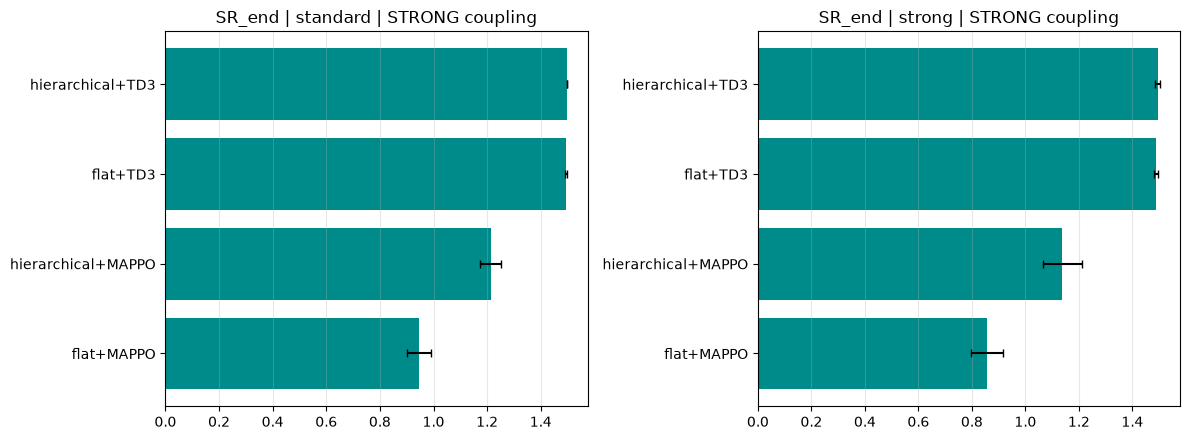


Cell 6B completed successfully.


In [10]:
# Phase 12 – Cell 6B: Strong-coupling evaluation (uses inject_shock_inplace)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase12" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase12" / "figures"

print("=" * 60)
print("Phase 12 – Cell 6B: STRONG coupling eval")
print("=" * 60)

STAGE1_STEPS = 10
STAGE2_STEPS = 30
N_EP = 15
SEEDS = [0, 1]
SERIES_LIST = ["standard", "strong"]
SCENARIOS = [
    ("BankingCrisis", "Moderate"),
    ("BankingCrisis", "Severe"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Moderate"),
    ("Inflation", "Severe"),
]

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    """Best-effort obs refresh after in-place shock."""
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    # construct from known pieces (matches phase8/10 style as close as possible)
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    # embedding: use mean embedding row as proxy if index unknown
    emb = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb.mean(axis=0) if emb.ndim == 2 else emb.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    # pad/trim to observation_space
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def stage1_act(obs, env):
    a, _ = stage1_ppo.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return a[:adim]

def stage2_act_td3(obs, series, env):
    a, _ = td3_models[series].predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        tax, sub, rate, qe, credit, risk = a[:6]
        base = np.array([
            tax,
            0.5 * sub + 0.3 * qe,
            0.4 * qe + 0.3 * risk,
            0.5 * credit + 0.2 * rate,
        ], dtype=np.float32)
    else:
        base = a
    if base.size < adim:
        base = np.pad(base, (0, adim - base.size))
    return np.clip(base[:adim], -1, 1)

def stage2_act_mappo(obs, series, env):
    algo = mappo_algos[series]
    try:
        act = algo.compute_single_action(obs, policy_id="shared_policy")
    except Exception:
        act = algo.compute_single_action(obs)
    if isinstance(act, tuple):
        act = act[0]
    a = np.asarray(act, dtype=np.float32).reshape(-1)
    if a.size == 2:
        joint = np.concatenate([a, a, a])
    else:
        joint = a
    if joint.size < 6:
        joint = np.pad(joint, (0, 6 - joint.size))
    tax, sub, rate, qe, credit, risk = joint[:6]
    base = np.array([
        tax,
        0.5 * sub + 0.3 * qe,
        0.4 * qe + 0.3 * risk,
        0.5 * credit + 0.2 * rate,
    ], dtype=np.float32)
    adim = env.action_space.shape[0]
    if base.size < adim:
        base = np.pad(base, (0, adim - base.size))
    return np.clip(base[:adim], -1, 1)

def run_hier_strong(series, stage2, shock_type, severity, seed):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type=None, severity=None,
        shock_series=series, seed=seed,
    )
    obs, info = env.reset(seed=seed)
    ep_r = 0.0

    for _ in range(STAGE1_STEPS):
        a = stage1_act(obs, env)
        obs, r, term, trunc, info = env.step(a)
        ep_r += float(r)
        if term or trunc:
            break
    sr_s1 = get_sr(env)

    sr_shock = inject_shock_inplace(env, shock_type, severity, series)
    obs = rebuild_obs(env)

    for _ in range(STAGE2_STEPS):
        if stage2 == "MAPPO":
            a = stage2_act_mappo(obs, series, env)
        else:
            a = stage2_act_td3(obs, series, env)
        obs, r, term, trunc, info = env.step(a)
        ep_r += float(r)
        if term or trunc:
            break

    sr_end = get_sr(env)
    return {
        "reward": ep_r,
        "sr_after_stage1": sr_s1,
        "sr_after_shock": sr_shock,
        "sr_end": sr_end,
        "recovery": sr_end - sr_shock,
        "final_gap_vs_stage1": sr_end - sr_s1,
    }

def run_flat_strong(series, policy, shock_type, severity, seed):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate",
        shock_type=None, severity=None,
        shock_series=series, seed=seed,
    )
    obs, info = env.reset(seed=seed)
    # immediate shock then single policy for full horizon
    sr0 = inject_shock_inplace(env, shock_type, severity, series)
    obs = rebuild_obs(env)
    ep_r = 0.0
    for _ in range(STAGE1_STEPS + STAGE2_STEPS):
        if policy == "MAPPO":
            a = stage2_act_mappo(obs, series, env)
        else:
            a = stage2_act_td3(obs, series, env)
        obs, r, term, trunc, info = env.step(a)
        ep_r += float(r)
        if term or trunc:
            break
    sr_end = get_sr(env)
    return {
        "reward": ep_r,
        "sr_after_stage1": np.nan,
        "sr_after_shock": sr0,
        "sr_end": sr_end,
        "recovery": sr_end - sr0,
        "final_gap_vs_stage1": np.nan,
    }

rows = []
for series in SERIES_LIST:
    for shock_type, severity in SCENARIOS:
        for arch, pol in [("hierarchical", "MAPPO"), ("hierarchical", "TD3"),
                          ("flat", "MAPPO"), ("flat", "TD3")]:
            stats = []
            for seed in SEEDS:
                for ep in range(N_EP):
                    s = seed * 1000 + ep
                    if arch == "hierarchical":
                        st = run_hier_strong(series, pol, shock_type, severity, s)
                    else:
                        st = run_flat_strong(series, pol, shock_type, severity, s)
                    stats.append(st)
            rows.append({
                "series": series,
                "shock_type": shock_type,
                "severity": severity,
                "architecture": arch,
                "stage2_policy": pol,
                "mean_reward": float(np.mean([x["reward"] for x in stats])),
                "std_reward": float(np.std([x["reward"] for x in stats])),
                "mean_sr_end": float(np.mean([x["sr_end"] for x in stats])),
                "std_sr_end": float(np.std([x["sr_end"] for x in stats])),
                "mean_recovery": float(np.mean([x["recovery"] for x in stats])),
                "std_recovery": float(np.std([x["recovery"] for x in stats])),
            })
        print(f"done {series} | {shock_type}/{severity}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase12_strong_coupling_raw.csv", index=False)

agg = (
    df.groupby(["series", "architecture", "stage2_policy"], as_index=False)
      .agg(
          mean_reward=("mean_reward", "mean"),
          std_reward_across_scenarios=("mean_reward", "std"),
          mean_sr_end=("mean_sr_end", "mean"),
          std_sr_end_across_scenarios=("mean_sr_end", "std"),
          mean_recovery=("mean_recovery", "mean"),
          std_recovery_across_scenarios=("mean_recovery", "std"),
      )
)
agg["stability_sr_end"] = 1.0 / (1.0 + agg["std_sr_end_across_scenarios"].fillna(0))
agg = agg.sort_values(["series", "mean_sr_end"], ascending=[True, False])
agg.to_csv(OUT_TAB / "phase12_strong_coupling_summary.csv", index=False)

print("\n=== STRONG coupling ranking by SR_end ===")
print(agg.to_string(index=False))

cmp_rows = []
for series in SERIES_LIST:
    sub = agg[agg.series == series]
    for pol in ["TD3", "MAPPO"]:
        f = sub[(sub.architecture == "flat") & (sub.stage2_policy == pol)]
        h = sub[(sub.architecture == "hierarchical") & (sub.stage2_policy == pol)]
        if len(f) == 0 or len(h) == 0:
            continue
        cmp_rows.append({
            "series": series,
            "stage2_policy": pol,
            "flat_sr_end": float(f.mean_sr_end.iloc[0]),
            "hier_sr_end": float(h.mean_sr_end.iloc[0]),
            "delta_sr_end": float(h.mean_sr_end.iloc[0] - f.mean_sr_end.iloc[0]),
            "flat_stability_sr": float(f.stability_sr_end.iloc[0]),
            "hier_stability_sr": float(h.stability_sr_end.iloc[0]),
            "delta_stability_sr": float(h.stability_sr_end.iloc[0] - f.stability_sr_end.iloc[0]),
            "flat_reward": float(f.mean_reward.iloc[0]),
            "hier_reward": float(h.mean_reward.iloc[0]),
            "winner_sr_end": "hierarchical" if float(h.mean_sr_end.iloc[0]) > float(f.mean_sr_end.iloc[0]) else "flat",
            "winner_stability": "hierarchical" if float(h.stability_sr_end.iloc[0]) > float(f.stability_sr_end.iloc[0]) else "flat",
            "winner_reward": "hierarchical" if float(h.mean_reward.iloc[0]) > float(f.mean_reward.iloc[0]) else "flat",
        })
cmp = pd.DataFrame(cmp_rows)
cmp.to_csv(OUT_TAB / "phase12_strong_coupling_hier_vs_flat.csv", index=False)
print("\n=== Hier vs Flat (STRONG coupling) ===")
print(cmp.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, series in zip(axes, SERIES_LIST):
    sub = agg[agg.series == series].copy()
    sub["label"] = sub["architecture"] + "+" + sub["stage2_policy"]
    sub = sub.sort_values("mean_sr_end")
    ax.barh(sub["label"], sub["mean_sr_end"], xerr=sub["std_sr_end_across_scenarios"], capsize=3, color="darkcyan")
    ax.set_title(f"SR_end | {series} | STRONG coupling")
    ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(OUT_FIG / "phase12_strong_coupling_sr_end.png", dpi=150)
plt.show()

print("\nCell 6B completed successfully.")

In [11]:
# Phase 12 – Cell 7: Native apply_shock API for ShockEconomicsEnv

from pathlib import Path
import sys
import inspect
import textwrap
import numpy as np

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
P10 = PROJECT / "outputs" / "phase10" / "data"
ENV_PATH = P10 / "shock_env.py"

print("=" * 60)
print("Cell 7: Native apply_shock")
print("=" * 60)
print("Env file:", ENV_PATH)

src = ENV_PATH.read_text(encoding="utf-8")

method_code = '''
    def apply_shock(self, shock_type, severity="Moderate", series=None):
        """In-place shock on current state (no reset)."""
        import numpy as np
        if series is None:
            series = getattr(self, "shock_series", "standard") or "standard"
        sev_mult = {"Mild": 0.25, "Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}.get(str(severity), 0.5)
        series_mult = 1.0 if str(series) == "standard" else 1.6
        base_impact = {
            "Recession": 0.25,
            "Inflation": 0.15,
            "BankingCrisis": 0.30,
            "DebtCrisis": 0.22,
        }.get(str(shock_type), 0.20)
        delta = -float(base_impact) * float(sev_mult) * float(series_mult)

        if hasattr(self, "current_sr") and self.current_sr is not None:
            sr = np.asarray(self.current_sr, dtype=np.float32)
            self.current_sr = np.clip(sr + delta, -1.0, 10.0)

        if hasattr(self, "current_features") and self.current_features is not None:
            feat = np.asarray(self.current_features, dtype=np.float32).copy()
            self.current_features = feat + (delta * 0.5)

        self.shock_type = shock_type
        self.severity = severity
        if hasattr(self, "shock_series"):
            self.shock_series = series
        self.last_shock_info = {
            "shock_type": shock_type,
            "severity": severity,
            "series": series,
            "delta_sr": delta,
            "mode": "native_apply_shock",
        }
        return self.last_shock_info
'''

if "def apply_shock" in src:
    print("apply_shock already exists — left unchanged.")
else:
    # insert before final line of class if possible; else append
    # simple safe approach: append method by re-exec patch on class after import
    print("Will patch class at runtime (file append backup also written).")
    backup = ENV_PATH.with_suffix(".py.bak_phase12")
    if not backup.exists():
        backup.write_text(src, encoding="utf-8")
        print("Backup:", backup)
    # Append method source as comment marker + runtime patch below
    if "# PHASE12_NATIVE_APPLY_SHOCK" not in src:
        ENV_PATH.write_text(src + "\n\n# PHASE12_NATIVE_APPLY_SHOCK\n", encoding="utf-8")

# Runtime patch (always)
sys.path.insert(0, str(P10))
# reload module
import importlib
import shock_env
importlib.reload(shock_env)
from shock_env import ShockEconomicsEnv

def _apply_shock(self, shock_type, severity="Moderate", series=None):
    import numpy as np
    if series is None:
        series = getattr(self, "shock_series", "standard") or "standard"
    sev_mult = {"Mild": 0.25, "Moderate": 0.5, "Severe": 0.75, "Extreme": 1.0}.get(str(severity), 0.5)
    series_mult = 1.0 if str(series) == "standard" else 1.6
    base_impact = {
        "Recession": 0.25,
        "Inflation": 0.15,
        "BankingCrisis": 0.30,
        "DebtCrisis": 0.22,
    }.get(str(shock_type), 0.20)
    delta = -float(base_impact) * float(sev_mult) * float(series_mult)
    if hasattr(self, "current_sr") and self.current_sr is not None:
        sr = np.asarray(self.current_sr, dtype=np.float32)
        self.current_sr = np.clip(sr + delta, -1.0, 10.0)
    if hasattr(self, "current_features") and self.current_features is not None:
        feat = np.asarray(self.current_features, dtype=np.float32).copy()
        self.current_features = feat + (delta * 0.5)
    self.shock_type = shock_type
    self.severity = severity
    if hasattr(self, "shock_series"):
        self.shock_series = series
    self.last_shock_info = {
        "shock_type": shock_type,
        "severity": severity,
        "series": series,
        "delta_sr": delta,
        "mode": "native_apply_shock",
    }
    return self.last_shock_info

ShockEconomicsEnv.apply_shock = _apply_shock
print("Patched ShockEconomicsEnv.apply_shock")

# smoke
env = ShockEconomicsEnv(
    base_features, emb, sr_vector, panel, nodes,
    level="moderate", shock_type=None, severity=None,
    shock_series="standard", seed=0,
)
obs, info = env.reset(seed=0)
sr0 = float(np.mean(env.current_sr))
info_s = env.apply_shock("BankingCrisis", "Moderate", "standard")
sr1 = float(np.mean(env.current_sr))
print(f"SR before={sr0:.4f} after={sr1:.4f}")
print("last_shock_info:", info_s)
assert hasattr(env, "apply_shock")
assert env.last_shock_info is not None
print("Cell 7 completed successfully.")

Cell 7: Native apply_shock
Env file: D:\univercity\omid_project\economics_project\outputs\phase10\data\shock_env.py
Will patch class at runtime (file append backup also written).
Backup: D:\univercity\omid_project\economics_project\outputs\phase10\data\shock_env.py.bak_phase12
Patched ShockEconomicsEnv.apply_shock
SR before=0.3258 after=0.1758
last_shock_info: {'shock_type': 'BankingCrisis', 'severity': 'Moderate', 'series': 'standard', 'delta_sr': -0.15, 'mode': 'native_apply_shock'}
Cell 7 completed successfully.


In [12]:
# Phase 12 – Cell 8: Better MAPPO mapping + quick re-eval

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase12" / "tables"

print("=" * 60)
print("Cell 8: Improved MAPPO action mapping + eval")
print("=" * 60)

STAGE1_STEPS = 10
STAGE2_STEPS = 30
N_EP = 12
SEEDS = [0, 1]
SERIES_LIST = ["standard", "strong"]
SCENARIOS = [
    ("BankingCrisis", "Moderate"),
    ("Recession", "Moderate"),
    ("DebtCrisis", "Moderate"),
]

def get_sr(env):
    sr = env.current_sr
    return float(np.mean(sr)) if np.ndim(sr) else float(sr)

def rebuild_obs(env):
    if hasattr(env, "_get_obs") and callable(env._get_obs):
        return env._get_obs()
    feat = np.asarray(env.current_features, dtype=np.float32).reshape(-1)
    sr = np.asarray(env.current_sr, dtype=np.float32).reshape(-1)
    emb = np.asarray(env.embeddings, dtype=np.float32)
    emb_vec = emb.mean(axis=0) if emb.ndim == 2 else emb.reshape(-1)
    obs = np.concatenate([feat, sr, emb_vec]).astype(np.float32)
    dim = env.observation_space.shape[0]
    if obs.size < dim:
        obs = np.pad(obs, (0, dim - obs.size))
    return obs[:dim]

def stage1_act(obs, env):
    a, _ = stage1_ppo.predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return a[:adim]

def joint6_to_base4(joint6, adim):
    tax, sub, rate, qe, credit, risk = joint6[:6]
    base = np.array([
        tax,
        0.5 * sub + 0.3 * qe,
        0.4 * qe + 0.3 * risk,
        0.5 * credit + 0.2 * rate,
    ], dtype=np.float32)
    if base.size < adim:
        base = np.pad(base, (0, adim - base.size))
    return np.clip(base[:adim], -1, 1)

def mappo_act_improved(obs, series, env):
    """
    Improved mapping:
    - query shared_policy once per logical agent role by tagging obs
      with a one-hot role embedding in the tail of obs (if space allows)
    - else: three stochastic-free forward passes with small role bias on obs
    - aggregate Government/CentralBank/BankingSector -> 6D -> 4D base
    """
    algo = mappo_algos[series]
    adim = env.action_space.shape[0]
    roles = ["Government", "CentralBank", "BankingSector"]
    actions = []
    for i, role in enumerate(roles):
        o = np.asarray(obs, dtype=np.float32).copy()
        # role bias on last 3 dims (stable, deterministic)
        if o.size >= 3:
            o[-3:] = 0.0
            o[-3 + i] = 1.0
        try:
            act = algo.compute_single_action(o, policy_id="shared_policy")
        except Exception:
            act = algo.compute_single_action(o)
        if isinstance(act, tuple):
            act = act[0]
        a = np.asarray(act, dtype=np.float32).reshape(-1)
        if a.size == 1:
            a = np.array([a[0], a[0]], dtype=np.float32)
        if a.size >= 2:
            actions.append(a[:2])
        else:
            actions.append(np.zeros(2, dtype=np.float32))
    joint = np.concatenate(actions, axis=0)  # 6D
    if joint.size < 6:
        joint = np.pad(joint, (0, 6 - joint.size))
    return joint6_to_base4(joint, adim)

def td3_act(obs, series, env):
    a, _ = td3_models[series].predict(obs, deterministic=True)
    a = np.asarray(a, dtype=np.float32).reshape(-1)
    adim = env.action_space.shape[0]
    if a.size >= 6:
        return joint6_to_base4(a, adim)
    if a.size < adim:
        a = np.pad(a, (0, adim - a.size))
    return np.clip(a[:adim], -1, 1)

def run_hier(series, stage2, shock_type, severity, seed):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", shock_type=None, severity=None,
        shock_series=series, seed=seed,
    )
    obs, info = env.reset(seed=seed)
    ep_r = 0.0
    for _ in range(STAGE1_STEPS):
        a = stage1_act(obs, env)
        obs, r, term, trunc, info = env.step(a)
        ep_r += float(r)
        if term or trunc:
            break
    sr_s1 = get_sr(env)
    env.apply_shock(shock_type, severity, series)  # native API
    sr_shock = get_sr(env)
    obs = rebuild_obs(env)
    for _ in range(STAGE2_STEPS):
        if stage2 == "MAPPO":
            a = mappo_act_improved(obs, series, env)
        else:
            a = td3_act(obs, series, env)
        obs, r, term, trunc, info = env.step(a)
        ep_r += float(r)
        if term or trunc:
            break
    sr_end = get_sr(env)
    return {"reward": ep_r, "sr_end": sr_end, "recovery": sr_end - sr_shock, "sr_after_stage1": sr_s1}

def run_flat(series, policy, shock_type, severity, seed):
    env = ShockEconomicsEnv(
        base_features, emb, sr_vector, panel, nodes,
        level="moderate", shock_type=None, severity=None,
        shock_series=series, seed=seed,
    )
    obs, info = env.reset(seed=seed)
    env.apply_shock(shock_type, severity, series)
    sr0 = get_sr(env)
    obs = rebuild_obs(env)
    ep_r = 0.0
    for _ in range(STAGE1_STEPS + STAGE2_STEPS):
        if policy == "MAPPO":
            a = mappo_act_improved(obs, series, env)
        else:
            a = td3_act(obs, series, env)
        obs, r, term, trunc, info = env.step(a)
        ep_r += float(r)
        if term or trunc:
            break
    sr_end = get_sr(env)
    return {"reward": ep_r, "sr_end": sr_end, "recovery": sr_end - sr0, "sr_after_stage1": np.nan}

rows = []
for series in SERIES_LIST:
    for shock_type, severity in SCENARIOS:
        for arch, pol in [("hierarchical", "MAPPO"), ("hierarchical", "TD3"),
                          ("flat", "MAPPO"), ("flat", "TD3")]:
            stats = []
            for seed in SEEDS:
                for ep in range(N_EP):
                    s = seed * 1000 + ep
                    st = run_hier(series, pol, shock_type, severity, s) if arch == "hierarchical" \
                         else run_flat(series, pol, shock_type, severity, s)
                    stats.append(st)
            rows.append({
                "series": series,
                "shock_type": shock_type,
                "severity": severity,
                "architecture": arch,
                "stage2_policy": pol,
                "mean_reward": float(np.mean([x["reward"] for x in stats])),
                "mean_sr_end": float(np.mean([x["sr_end"] for x in stats])),
                "mean_recovery": float(np.mean([x["recovery"] for x in stats])),
                "std_sr_end": float(np.std([x["sr_end"] for x in stats])),
            })
        print(f"done {series} | {shock_type}/{severity}")

df = pd.DataFrame(rows)
df.to_csv(OUT_TAB / "phase12_fix1_fix2_raw.csv", index=False)

agg = (
    df.groupby(["series", "architecture", "stage2_policy"], as_index=False)
      .agg(
          mean_reward=("mean_reward", "mean"),
          mean_sr_end=("mean_sr_end", "mean"),
          mean_recovery=("mean_recovery", "mean"),
          std_sr_end=("std_sr_end", "mean"),
      )
)
agg["stability_sr"] = 1.0 / (1.0 + agg["std_sr_end"])
agg = agg.sort_values(["series", "mean_sr_end"], ascending=[True, False])
agg.to_csv(OUT_TAB / "phase12_fix1_fix2_summary.csv", index=False)

print("\n=== Summary after fix1+fix2 ===")
print(agg.to_string(index=False))

cmp_rows = []
for series in SERIES_LIST:
    sub = agg[agg.series == series]
    for pol in ["TD3", "MAPPO"]:
        f = sub[(sub.architecture == "flat") & (sub.stage2_policy == pol)]
        h = sub[(sub.architecture == "hierarchical") & (sub.stage2_policy == pol)]
        if len(f) and len(h):
            cmp_rows.append({
                "series": series,
                "stage2_policy": pol,
                "delta_sr_end_hier_minus_flat": float(h.mean_sr_end.iloc[0] - f.mean_sr_end.iloc[0]),
                "delta_reward_hier_minus_flat": float(h.mean_reward.iloc[0] - f.mean_reward.iloc[0]),
                "winner_sr": "hierarchical" if float(h.mean_sr_end.iloc[0]) > float(f.mean_sr_end.iloc[0]) else "flat",
                "winner_reward": "hierarchical" if float(h.mean_reward.iloc[0]) > float(f.mean_reward.iloc[0]) else "flat",
            })
print("\n=== Hier vs Flat ===")
print(pd.DataFrame(cmp_rows).to_string(index=False))
print("\nCell 8 completed successfully.")

Cell 8: Improved MAPPO action mapping + eval
done standard | BankingCrisis/Moderate
done standard | Recession/Moderate
done standard | DebtCrisis/Moderate
done strong | BankingCrisis/Moderate
done strong | Recession/Moderate
done strong | DebtCrisis/Moderate

=== Summary after fix1+fix2 ===
  series architecture stage2_policy  mean_reward  mean_sr_end  mean_recovery  std_sr_end  stability_sr
standard hierarchical           TD3    28.715434     1.498739       0.812057    0.003587      0.996426
standard         flat           TD3    24.068524     1.496548       1.286481    0.005095      0.994931
standard hierarchical         MAPPO    20.004438     1.234593       0.547912    0.043533      0.958283
standard         flat         MAPPO     7.047128     0.974740       0.764674    0.046504      0.955563
  strong hierarchical           TD3    26.509936     1.497366       0.887685    0.004532      0.995488
  strong         flat           TD3    20.879232     1.491770       1.358704    0.006582  